# Tutorial 1 (AY24/25 Sem 1)

In [1]:
# Required imports
import sympy as sym
from ma1522 import Matrix

## Question 3
Solve the following linear systems.

### (a)
$$\begin{cases} 3x_1 & + & 2x_2 & - & 4x_3 & = & 3 \\
2x_1 & + & 3x_2 & + & 3x_3 & = & 15  \\
5x_1 & - & 3x_2 & + & x_3 & = & 14 \end{cases}$$

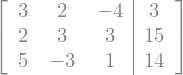

In [2]:
mat = Matrix([[3, 2, -4],
              [2, 3, 3],
              [5, -3, 1]])

aug = Matrix([3, 15, 14])

aug_mat = mat.row_join(aug)
aug_mat

<IPython.core.display.Math object>

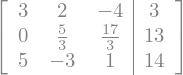

<IPython.core.display.Math object>

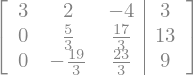

<IPython.core.display.Math object>

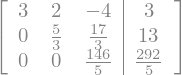

In [3]:
plu = aug_mat.ref() # Show steps to get to Row Echelon Form

In [4]:
plu.U.rref()  # Reduced Row Echelon Form from Upper Triangular Matrix

RREF(rref=Matrix([
[1, 0, 0 | 3]
[0, 1, 0 | 1]
[0, 0, 1 | 2]
]), pivots=(0, 1, 2))

### (b) 

$$\begin{cases} a &+& b &-& c &-& 2d &=& 0  \\
 2a &+& b &-& c &+& d &=& -2  \\
 -a &+& b &-& 3c &+& d &=& 4 \end{cases}$$



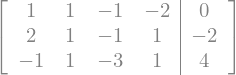

In [5]:
mat = Matrix([[1, 1, -1, -2],
              [2, 1, -1, 1],
              [-1, 1, -3, 1]])

aug = Matrix([0, -2, 4])

aug_mat = mat.row_join(aug)
aug_mat

In [6]:
aug_mat.rref() # Find Reduced Row Echelon Form

RREF(rref=Matrix([
[1, 0, 0,     3 | -2]
[0, 1, 0, -19/2 |  2]
[0, 0, 1,  -9/2 |  0]
]), pivots=(0, 1, 2))

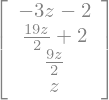

In [7]:
mat.solve(aug)[0]  # Solve the system of equations represented by the augmented matrix

### (c)

$$\begin{cases} x &-& 4y &+& 2z &=& -2  \\
 x &+& 2y &-& 2z &=& -3  \\
 x &-& y && &=& 4 \end{cases}$$


In [8]:
# add aug_pos to specify the position of the augmented column
aug_mat = Matrix([[1, -4, 2, -2],
                  [1, 2, -2, -3],
                  [1, -1, 0, 4]], aug_pos = 2)

aug_mat

Matrix([
[1, -4,  2 | -2]
[1,  2, -2 | -3]
[1, -1,  0 |  4]
])

In [9]:
aug_mat.rref()

RREF(rref=Matrix([
[1, 0, -2/3 | 0]
[0, 1, -2/3 | 0]
[0, 0,    0 | 1]
]), pivots=(0, 1, 3))

In [10]:
mat = aug_mat.select_cols(0, 1, 2)  # Remove the augmented column
aug = aug_mat.select_cols(3)  # Select the augmented column
# Solve the system of equations represented by the augmented matrix
try:
    mat.solve(aug)
except ValueError as e:
    print("Error raised due to inconsistent system:", e)

RREF(rref=Matrix([
[1, 0, -2/3 | 0]
[0, 1, -2/3 | 0]
[0, 0,    0 | 1]
]), pivots=(0, 1, 3))

Error raised due to inconsistent system: No solution found for the linear system. The system may be inconsistent.


## Question 4

Determine the values of $a$ and $b$ so that the linear system

$$\begin{cases} ax && &+& bz &=& 2  \\
 ax &+& ay &+& 4z &=& 4  \\
 && ay &+& 2z &=& b \end{cases}$$

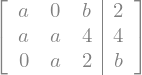

In [8]:
a, b = sym.symbols('a b') # Define symbolic variables

mat = Matrix([[a, 0, b, 2],
              [a, a, 4, 4],
              [0, a, 2, b]], aug_pos=2)

mat

### New method in v1.2 using `evaluate_cases()`

In v1.2, a new method `evaluate_cases(rhs, verbosity)` is introduced to check through all possible combinations at the same time using RREF. If `rhs` is not provided, it is treated as a homogenous system.

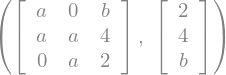

In [ ]:
# Require separation of A and b as it is a non-homogenous system
A = mat.select_cols(0, 1, 2)
b = mat.select_cols(3)

A, b

Branching on pivot at (0, 0) due to possibility of zero value with free symbols {a}
Branch 1 on pivot (0, 0) = 0 with conditions:


<IPython.core.display.Math object>

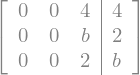

<IPython.core.display.Math object>

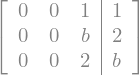

<IPython.core.display.Math object>

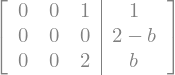

<IPython.core.display.Math object>

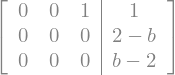



Branching on pivot at (1, 3) due to possibility of zero value with free symbols {b}
Branch 1 on pivot (1, 3) = 0 with conditions:


Completed branch with conditions:


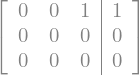



Branch 2 on pivot (1, 3) ≠ 0 with conditions:


<IPython.core.display.Math object>

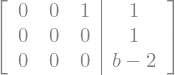

<IPython.core.display.Math object>

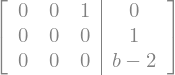

<IPython.core.display.Math object>

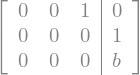

<IPython.core.display.Math object>

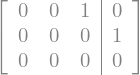



Completed branch with conditions:


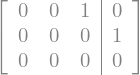



Branch 2 on pivot (0, 0) ≠ 0 with conditions:


<IPython.core.display.Math object>

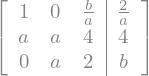

<IPython.core.display.Math object>

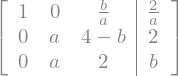



Branching on pivot at (1, 1) due to possibility of zero value with free symbols {a}
Branch 1 on pivot (1, 1) ≠ 0 with conditions:


<IPython.core.display.Math object>

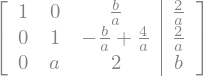

<IPython.core.display.Math object>

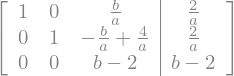



Branching on pivot at (2, 2) due to possibility of zero value with free symbols {b}
Branch 1 on pivot (2, 2) = 0 with conditions:


Completed branch with conditions:


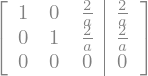



Branch 2 on pivot (2, 2) ≠ 0 with conditions:


<IPython.core.display.Math object>

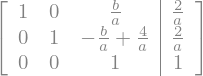

<IPython.core.display.Math object>

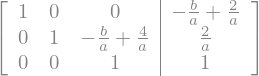

<IPython.core.display.Math object>

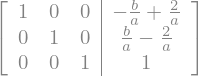



Completed branch with conditions:


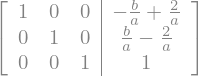



Summary of merged cases for non-homogeneous system:
Case 1: assume {a: 0}, excluding [{b: 2}]
No solution


RREF(rref=Matrix([
[0, 0, 1 | 0]
[0, 0, 0 | 1]
[0, 0, 0 | 0]
]), pivots=(2, 3))



Case 2: assume {}, excluding [{a: 0}, {b: 2}]
Unique solution


RREF(rref=Matrix([
[1, 0, 0 | -b/a + 2/a]
[0, 1, 0 |  b/a - 2/a]
[0, 0, 1 |          1]
]), pivots=(0, 1, 2))



Case 3: assume {b: 2}, excluding [{a: 0}]
Solution with 1 free parameter(s)


RREF(rref=Matrix([
[1, 0, 2/a | 2/a]
[0, 1, 2/a | 2/a]
[0, 0,   0 |   0]
]), pivots=(0, 1))



Case 4: assume {a: 0, b: 2}, excluding []
Solution with 2 free parameter(s)


RREF(rref=Matrix([
[0, 0, 1 | 1]
[0, 0, 0 | 0]
[0, 0, 0 | 0]
]), pivots=(2,))

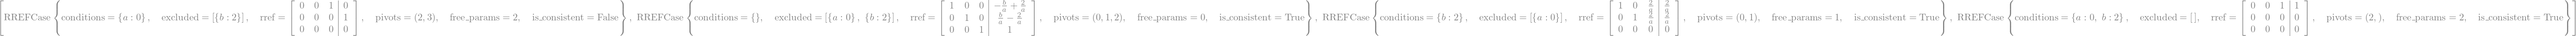

In [10]:
A.evaluate_cases(rhs=b, verbosity=2)

### Alternative Solution

This is an alternative method that that gives you more flexibility to do your own substitution.

In [ ]:
plu = mat.ref()  # Row Echelon Form using PLU decomposition

<IPython.core.display.Math object>

Matrix([
[a, 0,     b | 2]
[0, a, 4 - b | 2]
[0, a,     2 | b]
])

<IPython.core.display.Math object>

Matrix([
[a, 0,     b |     2]
[0, a, 4 - b |     2]
[0, 0, b - 2 | b - 2]
])

### (a) 

has no solution

In [13]:
# Case 1: b != 2, a = 0

plu.U.subs({a: 0}).rref()  # substitute a = 0

RREF(rref=Matrix([
[0, 0, 1 | 0]
[0, 0, 0 | 1]
[0, 0, 0 | 0]
]), pivots=(2, 3))

### (b) 

has only one solution

In [14]:
# Case 2: b != 2, a != 0

plu.U.rref()

RREF(rref=Matrix([
[1, 0, 0 | (2 - b)/a]
[0, 1, 0 | (b - 2)/a]
[0, 0, 1 |         1]
]), pivots=(0, 1, 2))

### (c) 

has infinitely many solutions and a general solution has one arbitrary parameter

In [15]:
# Case 3: b = 2, a != 0
plu.U.subs({b: 2}).rref()  # substitute b = 2

RREF(rref=Matrix([
[1, 0, 2/a | 2/a]
[0, 1, 2/a | 2/a]
[0, 0,   0 |   0]
]), pivots=(0, 1))

### (d) 

has infinitely many solutions and a general solution has two arbitrary parameters.

In [16]:
# Case 4: b = 2, a = 0
plu.U.subs({a: 0, b: 2}).rref()  # substitute a = 0 and b = 2

RREF(rref=Matrix([
[0, 0, 1 | 1]
[0, 0, 0 | 0]
[0, 0, 0 | 0]
]), pivots=(2,))

## Question 6

Solve the following system of non-linear equations:

$$\begin{cases} x^2 &-& y^2 &+& 2z^2 &=& 6  \\
 2x^2 &+& 2y^2 &-& 5z^2 &=& 3  \\
 2x^2 &+& 5y^2 &+& z^2 &=& 9 \end{cases}$$

In [17]:
mat = Matrix([[1, -1, 2, 6],
              [2, 2, -5, 3],
              [2, 5, 1, 9]], aug_pos=2)

mat

Matrix([
[1, -1,  2 | 6]
[2,  2, -5 | 3]
[2,  5,  1 | 9]
])

In [18]:
mat.rref()

RREF(rref=Matrix([
[1, 0, 0 | 4]
[0, 1, 0 | 0]
[0, 0, 1 | 1]
]), pivots=(0, 1, 2))

In [19]:
# Alternative Method: Using sym.solve

x, y, z = sym.symbols('x y z')  # Define symbolic variables for the solution

vec = Matrix([x**2, y**2, z**2])  # Define a vector of symbolic variables

mat = Matrix([[1, -1, 2],
              [2, 2, -5],
              [2, 5, 1]])

aug = Matrix([6, 3, 9])

mat, vec, aug

⎛             ⎡ 2⎤     ⎞
⎜             ⎢x ⎥     ⎟
⎜⎡1  -1  2 ⎤  ⎢  ⎥  ⎡6⎤⎟
⎜⎢         ⎥  ⎢ 2⎥  ⎢ ⎥⎟
⎜⎢2  2   -5⎥, ⎢y ⎥, ⎢3⎥⎟
⎜⎢         ⎥  ⎢  ⎥  ⎢ ⎥⎟
⎜⎣2  5   1 ⎦  ⎢ 2⎥  ⎣9⎦⎟
⎝             ⎣z ⎦     ⎠

In [20]:
sols = sym.solve(mat @ vec - aug)  # Solve the system of equations
for sol in sols:
    display(sol)  # Print the solutions for each variable

{x: -2, y: 0, z: -1}

{x: -2, y: 0, z: 1}

{x: 2, y: 0, z: -1}

{x: 2, y: 0, z: 1}

## Question 7

A network of one-way streets of a downtown section can be represented by the diagram below, with traffic flowing in the direction indicated. The average hourly volume of traffic entering and leaving this section during rush hour is given in the diagram.

<img src="https://raw.githubusercontent.com/YeeShin504/linear-algebra/master/docs/assets/images/Tut01Q7.png" alt="Tutorial 1 Question 7: Traffic Network">

### (a)
Do we have enough information to find the traffic volumes $x_1$, $x_2$, $x_3$, $x_4$, $x_5$, $x_6$, and $x_7$?

In [21]:
aug_mat = Matrix([[1, 0, 1, 0, 0, 0, 0, 800],
                  [1, -1, 0, 1, 0, 0, 0, 200],
                  [0, 1, 0, 0, -1, 0, 0, 500],
                  [0, 0, 1, 0, 0, 1, 0, 750],
                  [0, 0, 0, -1, 0, -1, 1, -600],
                  [0, 0, 0, 0, 1, 0, -1, -50]], aug_pos=6)

aug_mat

Matrix([
[1,  0, 1,  0,  0,  0,  0 |  800]
[1, -1, 0,  1,  0,  0,  0 |  200]
[0,  1, 0,  0, -1,  0,  0 |  500]
[0,  0, 1,  0,  0,  1,  0 |  750]
[0,  0, 0, -1,  0, -1,  1 | -600]
[0,  0, 0,  0,  1,  0, -1 |  -50]
])

In [22]:
aug_mat.rref()

RREF(rref=Matrix([
[1, 0, 0, 0, 0, -1,  0 |  50]
[0, 1, 0, 0, 0,  0, -1 | 450]
[0, 0, 1, 0, 0,  1,  0 | 750]
[0, 0, 0, 1, 0,  1, -1 | 600]
[0, 0, 0, 0, 1,  0, -1 | -50]
[0, 0, 0, 0, 0,  0,  0 |   0]
]), pivots=(0, 1, 2, 3, 4))

In [ ]:
mat = aug_mat.select_cols(*range(7))
aug = aug_mat.select_cols(7)

sol = mat.solve(aug)[0]
sol

Matrix([
[      y + 50]
[     z + 450]
[     750 - y]
[-y + z + 600]
[      z - 50]
[           y]
[           z]
])

### (b)
Suppose $x_6 = 50$ and $x_7 = 100$. What is $x_1$, $x_2$, $x_3$, $x_4$, and $x_5$?

In [24]:
y = sol[5]
z = sol[6]
sol.subs({y: 50, z: 100})  # Substitute y and z with specified values

Matrix([
[100]
[550]
[700]
[650]
[ 50]
[ 50]
[100]
])

### (c) 
Can the road between junction A and B be closed for construction while still keeping the traffic flowing in the same directions on the other streets? Explain.

In [25]:
sol.subs({y: -50}) # Set sol[0] = 0

Matrix([
[      0]
[z + 450]
[    800]
[z + 650]
[ z - 50]
[    -50]
[      z]
])